In [2]:
!pip install yfinance -q

In [3]:
import yfinance as yf

nifty = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

print(nifty.head())
print("Rows:", len(nifty))

[*********************100%***********************]  1 of 1 completed

Price         Adj Close        Close         High          Low         Open  \
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI        ^NSEI   
Date                                                                          
2015-01-02  8395.450195  8395.450195  8410.599609  8288.700195  8288.700195   
2015-01-05  8378.400391  8378.400391  8445.599609  8363.900391  8407.950195   
2015-01-06  8127.350098  8127.350098  8327.849609  8111.350098  8325.299805   
2015-01-07  8102.100098  8102.100098  8151.200195  8065.450195  8118.649902   
2015-01-08  8234.599609  8234.599609  8243.500000  8167.299805  8191.399902   

Price       Volume  
Ticker       ^NSEI  
Date                
2015-01-02  101900  
2015-01-05  118200  
2015-01-06  172800  
2015-01-07  164100  
2015-01-08  143800  
Rows: 2708


In [4]:
import pandas as pd

nifty = nifty.copy()

# Remove unnecessary column
nifty = nifty[['Open', 'High', 'Low', 'Close', 'Volume']]

# Check missing values
print(nifty.isnull().sum())

# Display data
print(nifty.head())

Price   Ticker
Open    ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Close   ^NSEI     0
Volume  ^NSEI     0
dtype: int64
Price              Open         High          Low        Close  Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI   ^NSEI
Date                                                                  
2015-01-02  8288.700195  8410.599609  8288.700195  8395.450195  101900
2015-01-05  8407.950195  8445.599609  8363.900391  8378.400391  118200
2015-01-06  8325.299805  8327.849609  8111.350098  8127.350098  172800
2015-01-07  8118.649902  8151.200195  8065.450195  8102.100098  164100
2015-01-08  8191.399902  8243.500000  8167.299805  8234.599609  143800


In [5]:
# Moving Averages
nifty['MA20'] = nifty['Close'].rolling(20).mean()
nifty['MA50'] = nifty['Close'].rolling(50).mean()

# Daily Return
nifty['Return'] = nifty['Close'].pct_change()

# Missing values created by rolling calculation
nifty = nifty.dropna()

print(nifty.head())
print("Rows:", len(nifty))

Price              Open         High          Low        Close  Volume  \
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI   ^NSEI   
Date                                                                     
2015-03-17  8689.099609  8742.549805  8630.799805  8723.299805  177000   
2015-03-18  8742.900391  8747.250000  8664.000000  8685.900391  156400   
2015-03-19  8749.450195  8788.200195  8614.650391  8634.650391  163500   
2015-03-20  8627.900391  8627.900391  8553.000000  8570.900391  174600   
2015-03-23  8591.549805  8608.349609  8540.549805  8550.900391  150700   

Price              MA20         MA50    Return  
Ticker                                          
Date                                            
2015-03-17  8799.122412  8669.166973  0.010442  
2015-03-18  8792.949951  8674.975977 -0.004287  
2015-03-19  8781.227490  8680.100977 -0.005900  
2015-03-20  8765.007520  8688.971982 -0.007383  
2015-03-23  8750.872559  8697.947988 -0.002333  
Rows: 2659


In [6]:
nifty['Target'] = (nifty['Close'].shift(-1) > nifty['Close']).astype(int)

nifty = nifty.dropna()

print(nifty[['Close', 'Target']].head())
print(nifty['Target'].value_counts())

Price             Close Target
Ticker            ^NSEI       
Date                          
2015-03-17  8723.299805      0
2015-03-18  8685.900391      0
2015-03-19  8634.650391      0
2015-03-20  8570.900391      0
2015-03-23  8550.900391      0
Target
1    1425
0    1234
Name: count, dtype: int64


In [7]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'Return']

X = nifty[features]
y = nifty['Target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2659, 8)
y shape: (2659,)


In [8]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2127, 8)
X_test: (532, 8)
y_train: (2127,)
y_test: (532,)


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (2127, 8)
X_test_scaled shape: (532, 8)


In [10]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print("X_train:", X_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([2127, 8])
X_test: torch.Size([532, 8])
y_train: torch.Size([2127])
y_test: torch.Size([532])


In [12]:
import torch.nn as nn

class NiftyLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64):
        super(NiftyLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = NiftyLSTM()

print(model)

NiftyLSTM(
  (lstm): LSTM(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [13]:
sequence_length = 10

X_train_seq = []
y_train_seq = []

for i in range(sequence_length, len(X_train_tensor)):
    X_train_seq.append(X_train_tensor[i-sequence_length:i])
    y_train_seq.append(y_train_tensor[i])

X_train_seq = torch.stack(X_train_seq)
y_train_seq = torch.stack(y_train_seq)

X_test_seq = []
y_test_seq = []

for i in range(sequence_length, len(X_test_tensor)):
    X_test_seq.append(X_test_tensor[i-sequence_length:i])
    y_test_seq.append(y_test_tensor[i])

X_test_seq = torch.stack(X_test_seq)
y_test_seq = torch.stack(y_test_seq)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: torch.Size([2117, 10, 8])
y_train_seq: torch.Size([2117])
X_test_seq: torch.Size([522, 10, 8])
y_test_seq: torch.Size([522])


In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_seq).squeeze()

    loss = criterion(outputs, y_train_seq)

    loss.backward()

    optimizer.step()

    predictions = (torch.sigmoid(outputs) >= 0.5).float()

    accuracy = (predictions == y_train_seq).float().mean() * 100

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {loss.item():.4f} "
        f"Accuracy: {accuracy.item():.2f}%"
    )

Epoch [1/10] Loss: 0.6910 Accuracy: 53.80%
Epoch [2/10] Loss: 0.6906 Accuracy: 53.80%
Epoch [3/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [4/10] Loss: 0.6903 Accuracy: 53.80%
Epoch [5/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [6/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [7/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [8/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [9/10] Loss: 0.6903 Accuracy: 53.80%
Epoch [10/10] Loss: 0.6903 Accuracy: 53.80%


In [15]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_seq).squeeze()
    predictions = (torch.sigmoid(outputs) >= 0.5).float()

    test_accuracy = (predictions == y_test_seq).float().mean() * 100

print("Test Accuracy:", round(test_accuracy.item(), 2), "%")

Test Accuracy: 53.45 %


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_seq.numpy(),
    predictions.numpy()
)

print(cm)

[[  0 243]
 [  0 279]]


In [18]:
print("Training Target:")
print(torch.bincount(y_train_seq.long()))

print("\nTest Target:")
print(torch.bincount(y_test_seq.long()))

Training Target:
tensor([ 978, 1139])

Test Target:
tensor([243, 279])


In [19]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_seq, y_train_seq)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [20]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {total_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.6920 Accuracy: 53.80%
Epoch [2/10] Loss: 0.6906 Accuracy: 53.80%
Epoch [3/10] Loss: 0.6902 Accuracy: 53.80%
Epoch [4/10] Loss: 0.6908 Accuracy: 53.80%
Epoch [5/10] Loss: 0.6894 Accuracy: 53.80%
Epoch [6/10] Loss: 0.6907 Accuracy: 53.80%
Epoch [7/10] Loss: 0.6894 Accuracy: 53.80%
Epoch [8/10] Loss: 0.6904 Accuracy: 53.80%
Epoch [9/10] Loss: 0.6901 Accuracy: 53.80%
Epoch [10/10] Loss: 0.6912 Accuracy: 53.80%


In [21]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_seq).squeeze()
    probabilities = torch.sigmoid(outputs)

print("Min probability:", probabilities.min().item())
print("Max probability:", probabilities.max().item())
print("Mean probability:", probabilities.mean().item())

Min probability: 0.5281123518943787
Max probability: 0.5397135615348816
Mean probability: 0.5321639776229858


In [22]:
print(model)

print("\nLSTM weight shape:")
print(model.lstm.weight_ih_l0.shape)

print("\nFC weight shape:")
print(model.fc.weight.shape)

NiftyLSTM(
  (lstm): LSTM(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

LSTM weight shape:
torch.Size([256, 8])

FC weight shape:
torch.Size([1, 64])


In [23]:
lr = 0.001

In [24]:
print("FC weight gradient:")
print(model.fc.weight.grad)

print("\nFC bias gradient:")
print(model.fc.bias.grad)

FC weight gradient:
tensor([[-3.4748e-03,  2.6414e-03, -3.5639e-02, -5.0754e-03, -3.6240e-05,
         -2.0301e-04, -9.3229e-04, -2.5785e-03, -4.9803e-05,  2.8229e-03,
          4.6910e-02,  1.2044e-02, -2.0365e-02,  3.2579e-03,  4.3033e-04,
          1.4815e-02,  1.8676e-04, -2.6086e-03,  8.4628e-03,  3.6237e-03,
         -3.6285e-02,  1.4781e-03, -2.0257e-03,  3.7287e-03,  8.9722e-04,
          1.3672e-02, -5.4882e-03, -2.9677e-02, -2.5765e-02,  3.5019e-04,
          6.4027e-04,  1.6021e-02, -1.6940e-03, -6.0976e-03, -5.7031e-05,
          2.0307e-04, -1.1302e-02, -8.8679e-04,  5.7216e-03,  4.0860e-04,
         -1.3620e-03, -1.0536e-02,  1.9988e-02, -3.5928e-03, -5.5010e-04,
          4.0367e-02, -9.7091e-03,  2.6638e-02,  7.2011e-03, -2.2872e-04,
          1.9594e-03,  1.3151e-04,  1.7185e-03,  7.0913e-05, -1.8709e-04,
          1.6430e-02,  2.1487e-02,  2.2667e-03,  4.5200e-02, -5.2835e-03,
         -5.7874e-02,  3.7335e-04,  3.9037e-02,  4.1230e-04]])

FC bias gradient:
tensor([0.

In [25]:
print("FC weight mean:", model.fc.weight.data.mean().item())
print("FC bias:", model.fc.bias.data.item())

FC weight mean: 0.0039133718237280846
FC bias: 0.07097304612398148


In [26]:
model = NiftyLSTM()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    accuracy = 100 * correct / total

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {total_loss/len(train_loader):.4f} "
            f"Accuracy: {accuracy:.2f}%"
        )

Epoch [10/100] Loss: 0.6902 Accuracy: 53.80%
Epoch [20/100] Loss: 0.6906 Accuracy: 53.80%
Epoch [30/100] Loss: 0.6915 Accuracy: 53.80%
Epoch [40/100] Loss: 0.6905 Accuracy: 53.80%
Epoch [50/100] Loss: 0.6896 Accuracy: 53.80%
Epoch [60/100] Loss: 0.6897 Accuracy: 53.80%
Epoch [70/100] Loss: 0.6883 Accuracy: 54.13%
Epoch [80/100] Loss: 0.6869 Accuracy: 54.32%
Epoch [90/100] Loss: 0.6876 Accuracy: 54.37%
Epoch [100/100] Loss: 0.6833 Accuracy: 54.79%


In [27]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_seq).squeeze()
    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities >= 0.5).float()

test_accuracy = (
    (predictions == y_test_seq).float().mean() * 100
)

print("Test Accuracy:", round(test_accuracy.item(), 2), "%")

Test Accuracy: 55.17 %


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_seq.numpy(),
    predictions.numpy()
)

print(cm)

[[108 135]
 [ 99 180]]


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_seq.numpy(),
    predictions.numpy(),
    target_names=["DOWN", "UP"]
))

              precision    recall  f1-score   support

        DOWN       0.52      0.44      0.48       243
          UP       0.57      0.65      0.61       279

    accuracy                           0.55       522
   macro avg       0.55      0.54      0.54       522
weighted avg       0.55      0.55      0.55       522



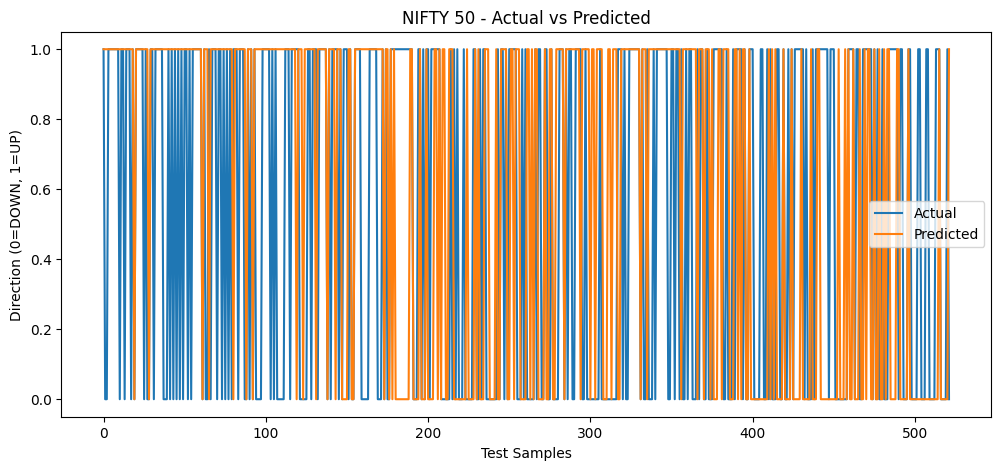

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test_seq.numpy(), label="Actual")
plt.plot(predictions.numpy(), label="Predicted")

plt.title("NIFTY 50 - Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Direction (0=DOWN, 1=UP)")
plt.legend()

plt.show()

In [32]:
torch.save(model.state_dict(), "nifty50_lstm_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [33]:
model.eval()

last_10_days = X_test_tensor[-10:].unsqueeze(0)

with torch.no_grad():
    output = model(last_10_days)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability >= 0.5 else 0

print("UP Probability:", round(probability, 4))
print("Prediction:", "UP" if prediction == 1 else "DOWN")

UP Probability: 0.4791
Prediction: DOWN


In [34]:
test_returns = nifty['Return'].iloc[-len(predictions):].values

In [36]:
positions = predictions.numpy()

In [37]:
strategy_returns = positions * test_returns

In [38]:
import numpy as np

strategy_cumulative = (1 + strategy_returns).cumprod() - 1
buy_hold_cumulative = (1 + test_returns).cumprod() - 1

print("Strategy Return:",
      round(strategy_cumulative[-1] * 100, 2), "%")

print("Buy & Hold Return:",
      round(buy_hold_cumulative[-1] * 100, 2), "%")

Strategy Return: 37.16 %
Buy & Hold Return: 32.68 %


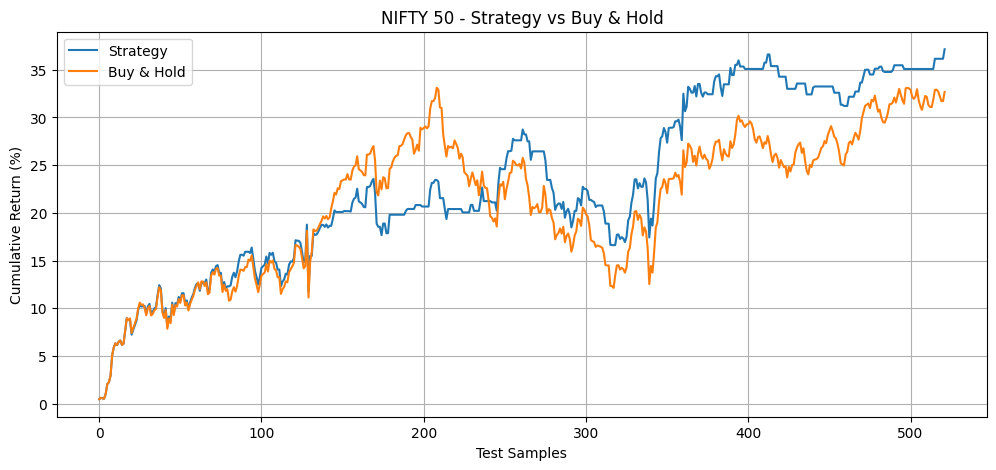

In [39]:
import matplotlib.pyplot as plt

strategy_cumulative = (1 + strategy_returns).cumprod() - 1
buy_hold_cumulative = (1 + test_returns).cumprod() - 1

plt.figure(figsize=(12, 5))

plt.plot(
    strategy_cumulative * 100,
    label="Strategy"
)

plt.plot(
    buy_hold_cumulative * 100,
    label="Buy & Hold"
)

plt.title("NIFTY 50 - Strategy vs Buy & Hold")
plt.xlabel("Test Samples")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)

plt.show()

In [40]:
torch.save(model.state_dict(), "nifty50_lstm_model.pth")

In [41]:
model = NiftyLSTM()

model.load_state_dict(
    torch.load("nifty50_lstm_model.pth")
)

model.eval()

last_10_days = X_test_tensor[-10:].unsqueeze(0)

with torch.no_grad():
    output = model(last_10_days)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability >= 0.5 else 0

print("UP Probability:", round(probability, 4))
print("Prediction:", "UP" if prediction == 1 else "DOWN")

UP Probability: 0.4791
Prediction: DOWN


In [42]:
import yfinance as yf
import pandas as pd
import torch

# Recent NIFTY 50 data
live_nifty = yf.download(
    "^NSEI",
    period="3mo",
    interval="1d",
    auto_adjust=False
)

live_nifty = live_nifty[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Features
live_nifty['MA20'] = live_nifty['Close'].rolling(20).mean()
live_nifty['MA50'] = live_nifty['Close'].rolling(50).mean()
live_nifty['Return'] = live_nifty['Close'].pct_change()

live_nifty = live_nifty.dropna()

features = [
    'Open', 'High', 'Low', 'Close',
    'Volume', 'MA20', 'MA50', 'Return'
]

# Same scaler used during training
live_scaled = scaler.transform(live_nifty[features])

# Last 10 days
last_10_days = torch.tensor(
    live_scaled[-10:],
    dtype=torch.float32
).unsqueeze(0)

# Load trained model
model = NiftyLSTM()
model.load_state_dict(
    torch.load("nifty50_lstm_model.pth")
)
model.eval()

# Prediction
with torch.no_grad():
    output = model(last_10_days)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability >= 0.5 else 0

print("Latest NIFTY 50 Close:",
      round(float(live_nifty['Close'].iloc[-1]), 2))

print("UP Probability:",
      round(probability, 4))

print("Prediction:",
      "UP" if prediction == 1 else "DOWN")

[*********************100%***********************]  1 of 1 completed

Latest NIFTY 50 Close: 23075.75
UP Probability: 0.469
Prediction: DOWN



/tmp/ipykernel_1069/2275101047.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  round(float(live_nifty['Close'].iloc[-1]), 2))


In [43]:
round(float(live_nifty['Close'].iloc[-1]), 2)

/tmp/ipykernel_1069/2665021304.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  round(float(live_nifty['Close'].iloc[-1]), 2)


23075.75

In [50]:
round(live_nifty['Close'].iloc[-1].item(), 2)

23075.75

In [48]:
print("Latest NIFTY 50 Close:",
      round(live_nifty['Close'].iloc[-1].item(), 2))

Latest NIFTY 50 Close: 23075.75


In [51]:
print("Latest NIFTY 50 Close:",
      round(live_nifty['Close'].iloc[-1].item(), 2))

Latest NIFTY 50 Close: 23075.75


In [52]:
print("===== NIFTY 50 DEEP LEARNING PROJECT RESULTS =====")
print("Training Accuracy : 54.79%")
print("Test Accuracy     : 55.17%")
print("Strategy Return   : 37.16%")
print("Buy & Hold Return : 32.68%")
print("Live NIFTY Close  : 23075.75")
print("Live UP Probability: 46.90%")
print("Live Prediction   : DOWN")

===== NIFTY 50 DEEP LEARNING PROJECT RESULTS =====
Training Accuracy : 54.79%
Test Accuracy     : 55.17%
Strategy Return   : 37.16%
Buy & Hold Return : 32.68%
Live NIFTY Close  : 23075.75
Live UP Probability: 46.90%
Live Prediction   : DOWN
